# Modeling open journeys

This notebook trains a random forest using point-in-time journey snapshots. The important correction is that shipped journeys are featurized only with events that happened before `order_shipped`, and inactive journeys are featurized before the 60-day inactivity outcome is known. That keeps the model closer to the actual prediction task: scoring journeys that are currently open.

# Modeling open journeys

This notebook trains a random forest using point-in-time journey snapshots. The important correction is that shipped journeys are featurized only with events that happened before `order_shipped`, and inactive journeys are featurized before the 60-day inactivity outcome is known. That keeps the model closer to the actual prediction task: scoring journeys that are currently open.

In [64]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

BASE_DIR = Path.cwd()
if not (BASE_DIR / 'dat_train1.csv').exists() and (BASE_DIR / 'joel' / 'dat_train1.csv').exists():
    BASE_DIR = BASE_DIR / 'joel'

TRAIN_PATH = BASE_DIR / 'dat_train1.csv'
OPEN_PATH = BASE_DIR / 'open_journeys1_flattened_all0.csv'
PREDICTION_PATH = BASE_DIR / 'open_journey_predictions.csv'
IMPORTANCE_PATH = BASE_DIR / 'model_variable_importance.png'

SELECTED_EVENTS = [
    'browse_products', 'view_cart', 'add_to_cart', 'begin_checkout',
    'place_order_web', 'place_order_phone', 'place_downpayment',
    'application_web_view', 'application_web_submit', 'application_web_approved',
    'promotion_created', 'campaignemail_clicked', 'campaign_click'
]


In [65]:
def build_features(events):
    events = events.sort_values(['id', 'event_timestamp']).copy()
    grouped = events.groupby('id')

    features = grouped.agg(
        n_events=('event_name', 'size'),
        n_unique_events=('event_name', 'nunique'),
        first_event_time=('event_timestamp', 'min'),
        last_event_time=('event_timestamp', 'max'),
    )
    features['journey_duration_days'] = (
        features['last_event_time'] - features['first_event_time']
    ).dt.total_seconds() / (60 * 60 * 24)

    event_counts = (
        events[events['event_name'].isin(SELECTED_EVENTS)]
        .groupby(['id', 'event_name'])
        .size()
        .unstack(fill_value=0)
    )
    event_counts = event_counts.reindex(columns=SELECTED_EVENTS, fill_value=0)
    event_counts = event_counts.add_prefix('n_')

    last_events = grouped.tail(1).set_index('id')['event_name']
    for event_name in SELECTED_EVENTS:
        features[f'last_is_{event_name}'] = (last_events == event_name).astype(int)

    features = features.join(event_counts, how='left').fillna(0)
    return features.drop(columns=['first_event_time', 'last_event_time'])


def make_training_snapshots(df, max_training_rows=200_000):
    cutoff_date = df['event_timestamp'].max() - pd.Timedelta(days=60)

    first_ship = (
        df.loc[df['event_name'] == 'order_shipped']
        .groupby('id')['event_timestamp']
        .min()
        .rename('first_ship_time')
    )
    last_event_time = df.groupby('id')['event_timestamp'].max().rename('last_event_time')
    journey_status = pd.concat([first_ship, last_event_time], axis=1)

    positive_ids = journey_status.index[journey_status['first_ship_time'].notna()]
    negative_ids = journey_status.index[
        journey_status['first_ship_time'].isna()
        & (journey_status['last_event_time'] < cutoff_date)
    ]

    labels = pd.concat([
        pd.Series(1, index=positive_ids, name='will_ship'),
        pd.Series(0, index=negative_ids, name='will_ship'),
    ])

    if len(labels) > max_training_rows:
        per_class = min(max_training_rows // 2, labels.value_counts().min())
        labels = labels.groupby(labels).sample(n=per_class, random_state=123).sort_index()

    selected_events = df[df['id'].isin(labels.index)].merge(
        first_ship, left_on='id', right_index=True, how='left'
    )
    snapshot_events = selected_events[
        selected_events['first_ship_time'].isna()
        | (selected_events['event_timestamp'] < selected_events['first_ship_time'])
    ].drop(columns=['first_ship_time'])

    features = build_features(snapshot_events)
    labels = labels.reindex(features.index)
    return features, labels, cutoff_date


In [66]:
df = pd.read_csv(
    TRAIN_PATH,
    usecols=['id', 'event_name', 'event_timestamp'],
    parse_dates=['event_timestamp'],
)
df = df.drop_duplicates(subset=['id', 'event_name', 'event_timestamp']).copy()
df['event_timestamp'] = pd.to_datetime(df['event_timestamp'], utc=True)

df.shape


(51848861, 3)

In [67]:
X, y, cutoff_date = make_training_snapshots(df)

print('Open-window cutoff date:', cutoff_date)
print('Training snapshot shape:', X.shape)
print(y.value_counts().rename(index={0: 'inactive', 1: 'will ship'}))


Open-window cutoff date: 2022-11-24 12:29:56+00:00
Training snapshot shape: (199983, 29)
will_ship
inactive     100000
will ship     99983
Name: count, dtype: int64


In [68]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=250,
    min_samples_leaf=10,
    max_features='sqrt',
    n_jobs=-1,
    oob_score=True,
    random_state=42,
)
rf.fit(X_train, y_train)

print('OOB accuracy:', rf.oob_score_)
print('Validation accuracy:', rf.score(X_valid, y_valid))
print(confusion_matrix(y_valid, rf.predict(X_valid)))
print(classification_report(y_valid, rf.predict(X_valid)))


OOB accuracy: 0.9821917899551295
Validation accuracy: 0.9820185614849188
[[24483   517]
 [  382 24614]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     25000
           1       0.98      0.98      0.98     24996

    accuracy                           0.98     49996
   macro avg       0.98      0.98      0.98     49996
weighted avg       0.98      0.98      0.98     49996



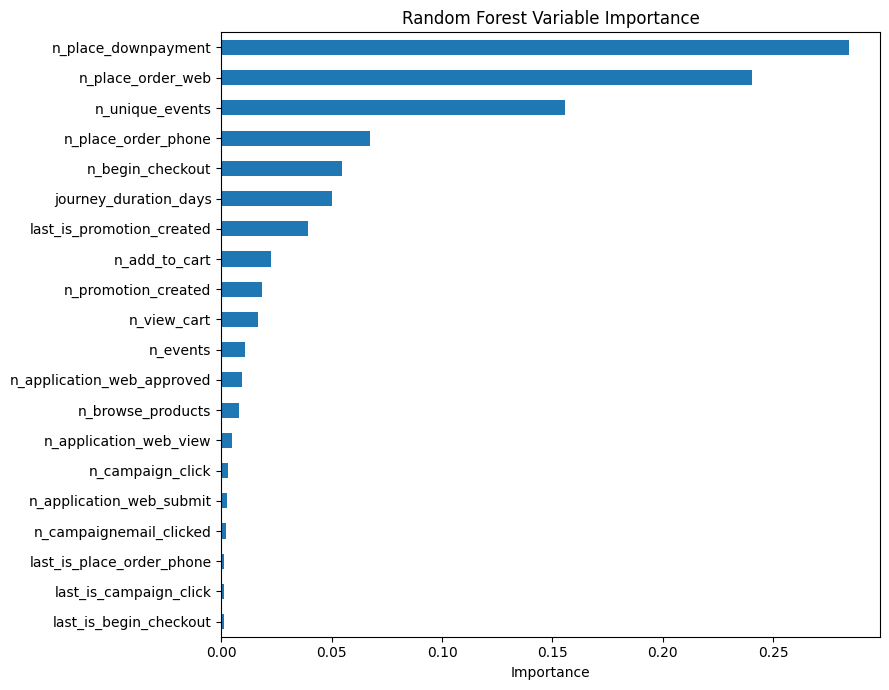

In [69]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values().tail(20)

plt.figure(figsize=(9, 7))
importances.plot(kind='barh')
plt.title('Random Forest Variable Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(IMPORTANCE_PATH, dpi=150)
plt.show()


In [70]:
open_journeys = pd.read_csv(OPEN_PATH)
open_events = df[df['id'].isin(open_journeys['id'])]

X_open = build_features(open_events).reindex(open_journeys['id']).fillna(0)
X_open = X_open.reindex(columns=X.columns, fill_value=0)

open_journeys['ship_probability'] = rf.predict_proba(X_open)[:, 1]
open_journeys['predicted_order_shipped'] = (open_journeys['ship_probability'] >= 0.5).astype(int)
open_journeys.to_csv(PREDICTION_PATH, index=False)

open_journeys.head()


,id,order_shipped,ship_probability,predicted_order_shipped
0,-1000001271 551641434,0,0.008728,0
1,-100001164 -1710062169,0,0.018156,0
2,-1000073039 494887319,0,0.007499,0
3,-1000092799 -1963858498,0,0.000827,0
4,-100009516 1394046265,0,0.018115,0


## Strategy notes

The training target is `will_ship`: 1 if the journey later has `order_shipped`, 0 if it has no shipment and becomes inactive for at least 60 days. For positive examples, features are built only from events before the first shipment. For negative examples, features are built from old non-shipped journeys whose last activity is before the 60-day cutoff. The model intentionally avoids `journey_steps_until_end` because that field describes the completed journey and would leak future information.

In [72]:
pd.read_csv("open_journeys1_flattened_all0.csv")

,id,order_shipped
0,-1000001271 551641434,0
1,-100001164 -1710062169,0
2,-1000073039 494887319,0
3,-1000092799 -1963858498,0
4,-100009516 1394046265,0
...,...,...
158320,999933969 -1955861701,0
158321,999941382 -125792206,0
158322,999956624 1573999787,0
158323,999981795 335952723,0


In [ ]:
submission = pd.read_csv("open_journey_predictions.csv")[['id', 'predicted_order_shipped']]

submission.columns = ['id', 'order_shipped']  # match expected format

submission.to_csv('submission.csv', index=False)